In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import joblib
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(style="whitegrid")

csv_file_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_file_path = os.path.join(dirname, filename)
            break

df = pd.read_csv(csv_file_path)

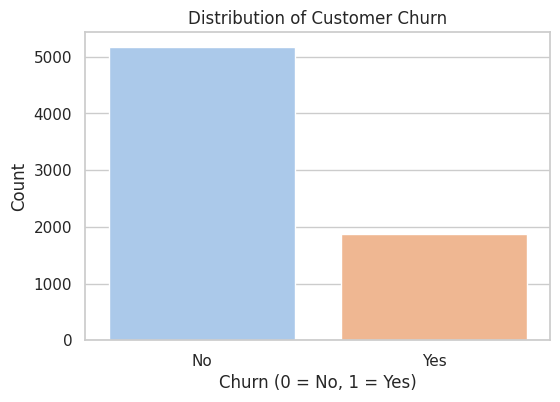

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [24]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True, errors='ignore')

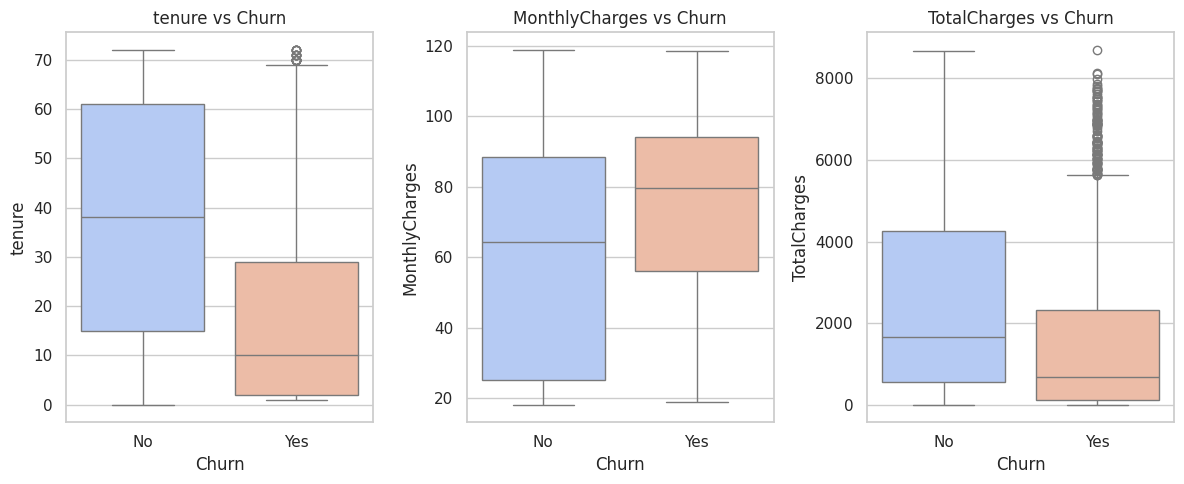

In [25]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], x=df['Churn'], palette='coolwarm')
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

In [26]:
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, 100], labels=['0-1 Yr', '1-2 Yrs', '2-4 Yrs', '4-5 Yrs', '5+ Yrs'])
df['Monthly_Variance'] = (df['TotalCharges'] / (df['tenure'] + 1)) - df['MonthlyCharges']

df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df = pd.get_dummies(df, drop_first=True)

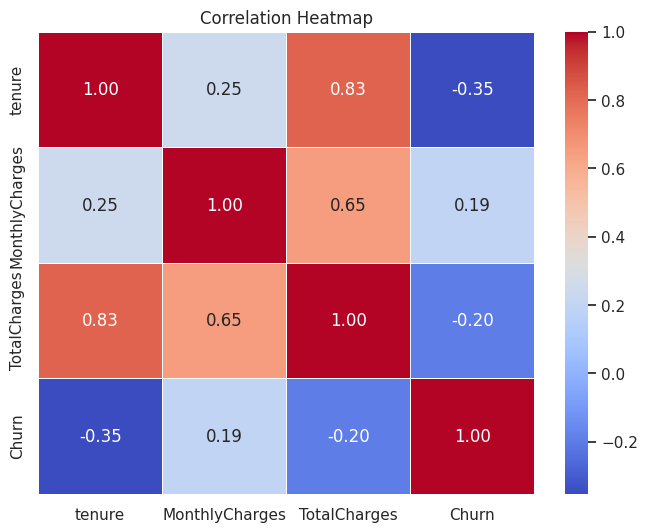

In [27]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

In [28]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [29]:
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC Score: 0.8424927019556175


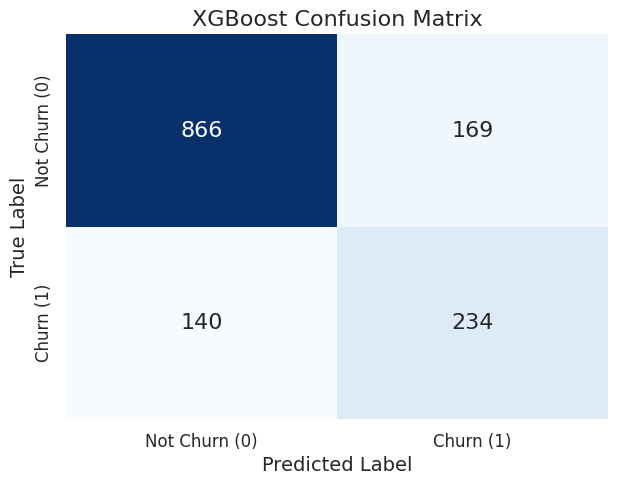

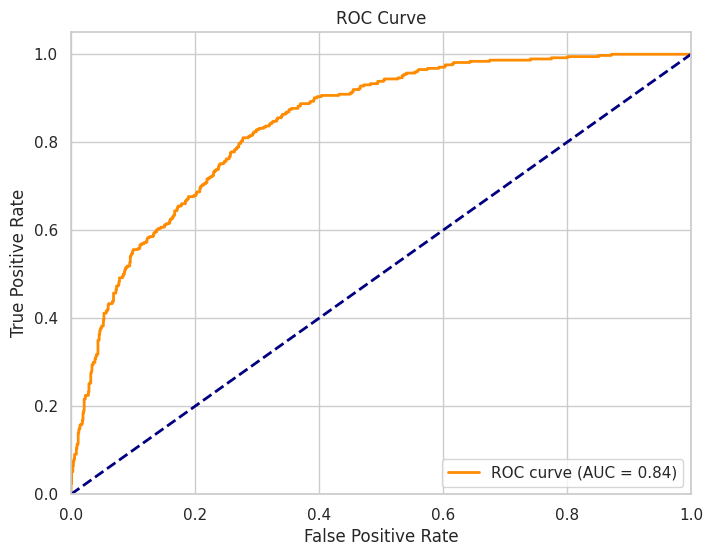

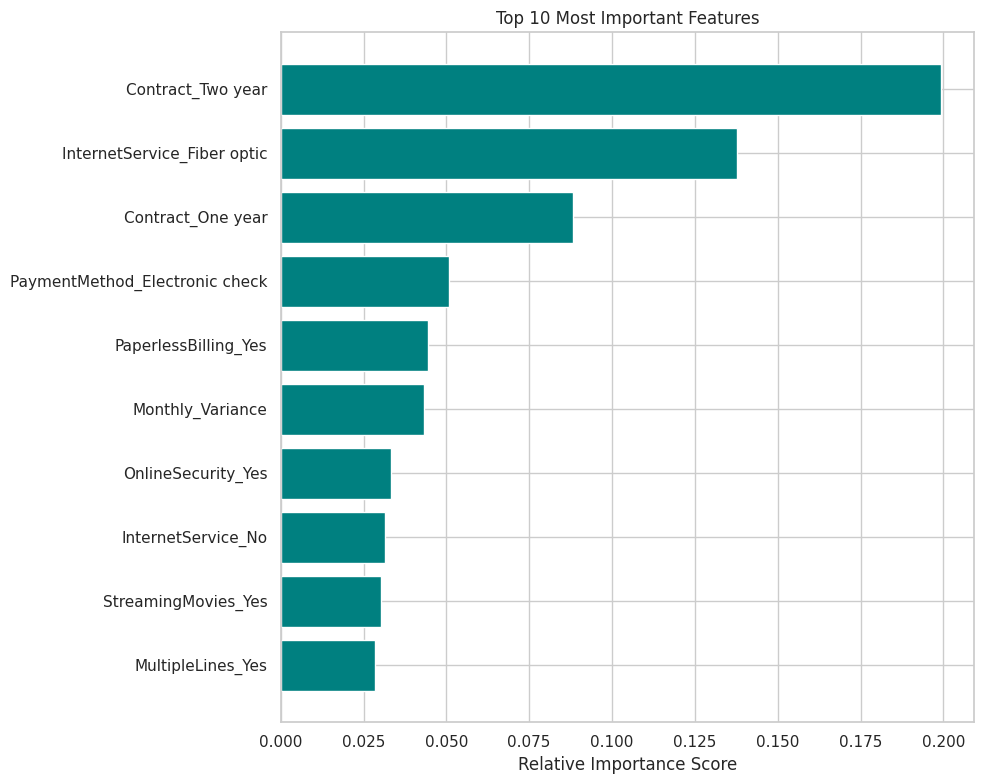

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('XGBoost Confusion Matrix', fontsize=16)
plt.xticks([0.5, 1.5], ['Not Churn (0)', 'Churn (1)'], fontsize=12)
plt.yticks([0.5, 1.5], ['Not Churn (0)', 'Churn (1)'], fontsize=12)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

importances = xgb_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
top_k = 10
top_indices = indices[:top_k]

plt.figure(figsize=(10, 8))
plt.title('Top 10 Most Important Features')
plt.barh(range(top_k), importances[top_indices], align='center', color='teal')
plt.yticks(range(top_k), [feature_names[i] for i in top_indices])
plt.xlabel('Relative Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
joblib.dump(xgb_model, 'xgb_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'features.pkl')

['features.pkl']